# Module 3 — Decision Tree Classification
## Erythemato-Squamous Disease Classification
### Dermatology Dataset (366 patients · 34 features · 6 disease classes)
---
**Trees:** Gini (full depth) · Entropy (depth=4) · Gini (depth=3)  
**Dataset:** [df_saved.csv](df_saved.csv) — same dataset used in Multinomial NB  
**Split:** 80/20 stratified train/test · `random_state=42`

---
## 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')
print("All imports successful.")

All imports successful.


---
## 2. Load & Inspect the Dataset

In [ ]:
# from google.colab import drive; drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/df_saved.csv')
df = pd.read_csv('df_saved.csv')
df['age'] = df['age'].fillna(df['age'].median())

disease_names = {1:'Psoriasis',2:'Seborrheic Dermatitis',3:'Lichen Planus',
                 4:'Pityriasis Rosea',5:'Chronic Dermatitis',6:'Pityriasis Rubra Pilaris'}

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nClass distribution:")
for cls, cnt in df['class'].value_counts().sort_index().items():
    print(f"  Class {cls} ({disease_names[cls]:<26s}): {cnt} ({cnt/len(df)*100:.1f}%)")
print(f"\nFirst 5 rows:\n{df.head().to_string()}")

Shape: 366 rows × 35 columns

Class distribution:
  Class 1 (Psoriasis                  ): 112 (30.6%)
  Class 2 (Seborrheic Dermatitis      ):  61 (16.7%)
  Class 3 (Lichen Planus              ):  72 (19.7%)
  Class 4 (Pityriasis Rosea           ):  49 (13.4%)
  Class 5 (Chronic Dermatitis         ):  52 (14.2%)
  Class 6 (Pityriasis Rubra Pilaris   ):  20 ( 5.5%)

First 5 rows:
   erythema  scaling  definite_borders  itching  ...  age  class
0         2        2                 0        3  ...  55.0      2
1         3        3                 3        2  ...   8.0      1
2         2        1                 2        3  ...  26.0      3
3         2        2                 2        2  ...  40.0      1
4         2        3                 2        2  ...  45.0      3


---
## 3. Decision Tree — Overview

### (a) What is a Decision Tree?
A Decision Tree recursively partitions the feature space into regions, each associated with a class prediction. At each internal **node**, the algorithm selects the feature and threshold that best reduces class impurity; **leaves** contain the final predictions. Because the result is a tree of human-readable if–then rules, Decision Trees are the most interpretable family of classifiers in machine learning — a clinician can trace the exact path from symptoms to diagnosis.

---
### Gini Impurity  
**Gini = 1 − Σ pᵢ²**  
Ranges from 0 (pure node, one class only) to 0.5 (maximally mixed for 2 classes).  
Lower is better — we want splits that produce purer child nodes.

### Entropy (Information)  
**H = −Σ pᵢ log₂(pᵢ)**  
Ranges from 0 (pure) to log₂(k) for k classes.  
Measures the "surprise" or uncertainty in a node.

### Information Gain  
**IG = Impurity(parent) − Σ [wᵢ × Impurity(childᵢ)]**  
Measures how much a split reduces impurity. The DT algorithm greedily selects the split with the **highest IG** at every node.

### Why can infinitely many trees exist?  
With 34 features and continuous thresholds, the number of valid splits per node is effectively infinite. Trees can grow to any depth, and different split orderings produce different topologies with equal or near-equal training accuracy — making depth constraints and pruning essential.

**Below: a worked numerical example for Gini, Entropy, and Information Gain:**

WORKED EXAMPLE: 24 patients — Classes A=10, B=10, C=4
PARENT NODE: A=10, B=10, C=4
  Gini    = 0.6250
  Entropy = 1.5022 bits

SPLIT ON X ≤ 1:
  Left  (14 pts) — A=10, B=0, C=0
    Gini=0.0000  Entropy=0.0000  (PURE)
  Right (10 pts) — A=0, B=10, C=4
    Gini=0.4082  Entropy=0.8632

INFORMATION GAIN:
  IG(Gini)    = 0.6250 − 0.1701 = 0.4549
  IG(Entropy) = 1.5022 − 0.3597 = 1.1425

→ A higher IG means a better split.
→ The DT algorithm picks the split with the HIGHEST IG at every node.


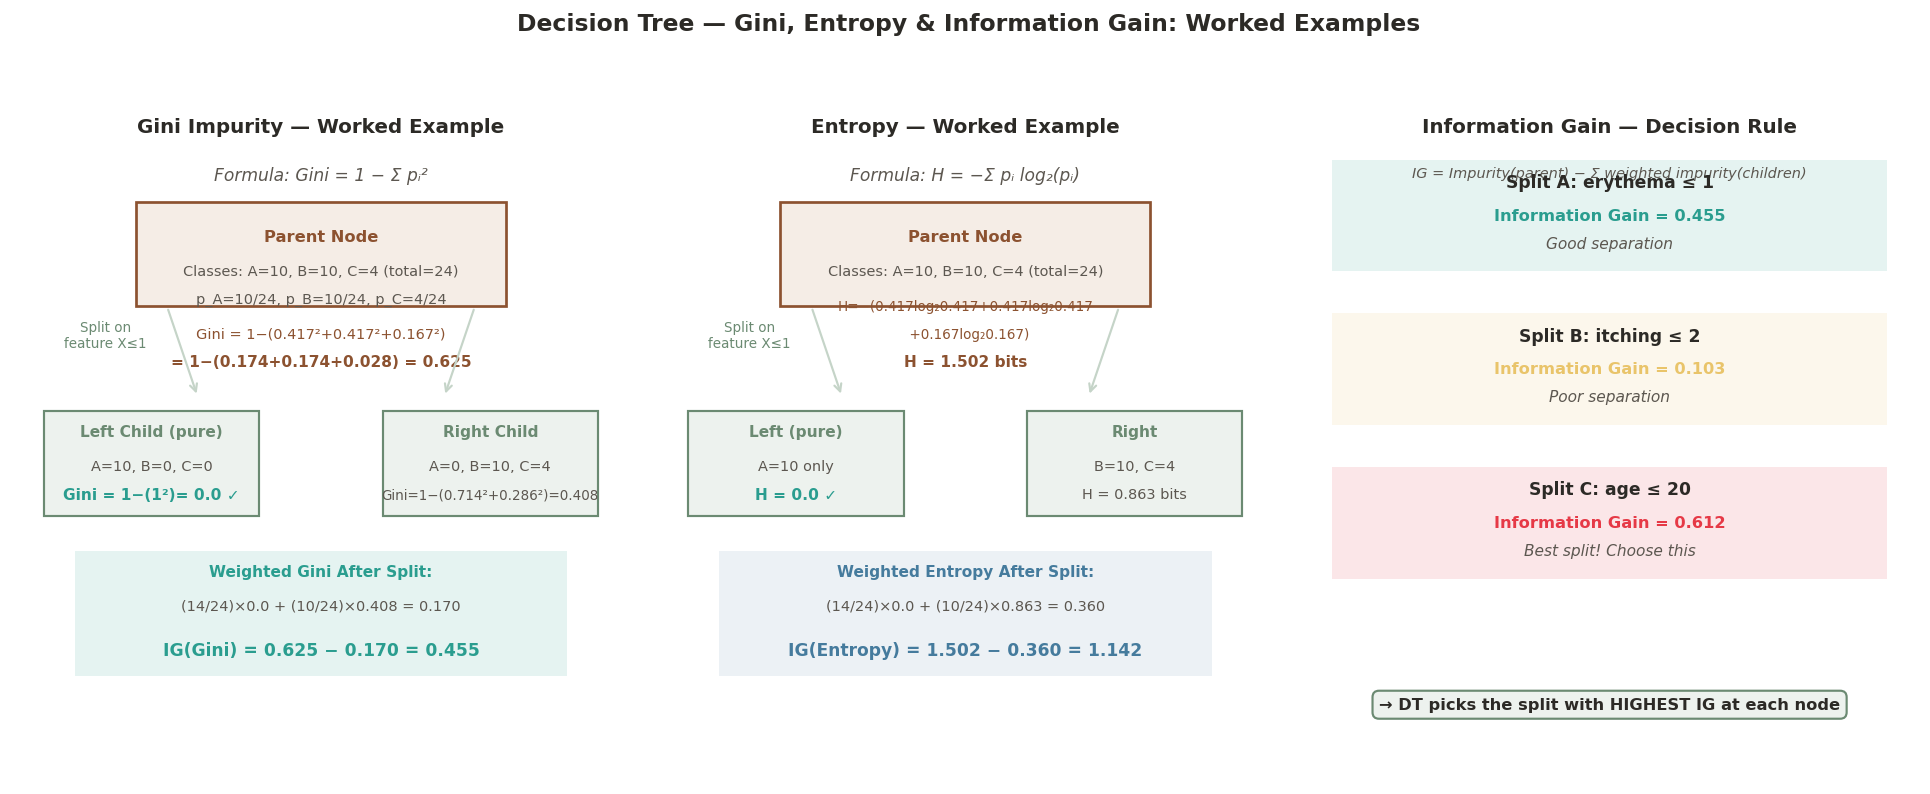

In [ ]:
# ── WORKED EXAMPLE: Gini, Entropy, and Information Gain ──
# Parent node: 24 patients, 3 classes  (A=10, B=10, C=4)
# Split on feature X ≤ 1
# Left child:  A=10, B=0,  C=0  (14 patients)
# Right child: A=0,  B=10, C=4  (14 patients)

import math
def gini(counts):
    n = sum(counts); return 1 - sum((c/n)**2 for c in counts if c>0)
def entropy(counts):
    n = sum(counts); return -sum((c/n)*math.log2(c/n) for c in counts if c>0)

parent=[10,10,4]; left=[10,0,0]; right=[0,10,4]
n=sum(parent); nl=sum(left); nr=sum(right)

g_parent=gini(parent); g_left=gini(left); g_right=gini(right)
h_parent=entropy(parent); h_left=entropy(left); h_right=entropy(right)

wg_after = (nl/n)*g_left + (nr/n)*g_right
wh_after = (nl/n)*h_left + (nr/n)*h_right

print("=" * 52)
print("WORKED EXAMPLE: 24 patients — Classes A=10, B=10, C=4")
print("=" * 52)
print(f"PARENT NODE: A={parent[0]}, B={parent[1]}, C={parent[2]}")
print(f"  Gini    = {g_parent:.4f}")
print(f"  Entropy = {h_parent:.4f} bits")
print()
print(f"SPLIT ON X ≤ 1:")
print(f"  Left  ({nl} pts) — A={left[0]}, B={left[1]}, C={left[2]}")
print(f"    Gini={g_left:.4f}  Entropy={h_left:.4f}  (PURE)")
print(f"  Right ({nr} pts) — A={right[0]}, B={right[1]}, C={right[2]}")
print(f"    Gini={g_right:.4f}  Entropy={h_right:.4f}")
print()
print(f"INFORMATION GAIN:")
print(f"  IG(Gini)    = {g_parent:.4f} − {wg_after:.4f} = {g_parent-wg_after:.4f}")
print(f"  IG(Entropy) = {h_parent:.4f} − {wh_after:.4f} = {h_parent-wh_after:.4f}")
print()
print("→ A higher IG means a better split.")
print("→ The DT algorithm picks the split with the HIGHEST IG at every node.")

---
## 4. Data Preparation — Train / Test Split

### (b) Data Prep
Decision Trees natively handle ordinal integer features without scaling — **no StandardScaler required**.  
The same `df_saved.csv` dataset used for Multinomial NB is used here (linked above).

**Why must train and test be disjoint?**  
The model is built entirely on the training set. If any test patient were seen during training, the model could simply memorise that patient's label rather than learning a generalisable pattern, inflating accuracy. **Stratification** preserves disease class proportions in both sets, ensuring rare classes (e.g. Class 6 — 20 patients total) are represented in both splits.

TRAIN / TEST SPLIT — DECISION TREE
Training set: 292 rows × 34 features (80%)
Test set:     74 rows × 34 features (20%)

Per-class counts:
  Class                               Train    Test
  ------------------------------------------------
  Psoriasis                             89       23
  Seborrheic Dermatitis                 49       12
  Lichen Planus                         58       15
  Pityriasis Rosea                      39       10
  Chronic Dermatitis                    41       10
  Pityriasis Rubra Pilaris              16        4

Training set — first 5 rows:
   erythema  scaling  definite_borders  ...  band_like_infiltrate   age
...
Test set — first 5 rows:
   erythema  scaling  definite_borders  ...  band_like_infiltrate   age
...


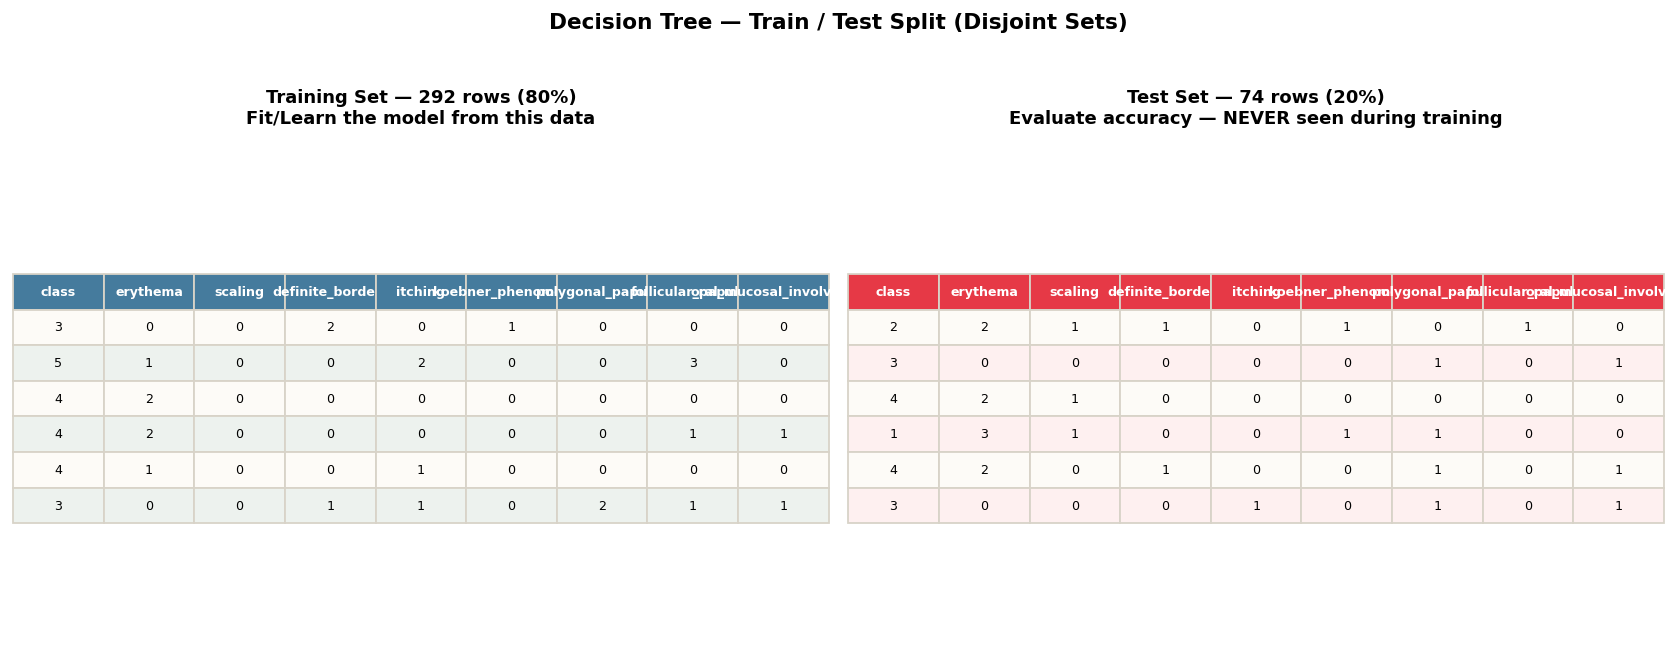

In [ ]:
X = df.drop(columns=['class'])
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)

print("=" * 60)
print("TRAIN / TEST SPLIT — DECISION TREE")
print("=" * 60)
print(f"Training set: {X_train.shape[0]} rows × {X_train.shape[1]} features (80%)")
print(f"Test set:     {X_test.shape[0]} rows × {X_test.shape[1]} features (20%)")
print()
print("Per-class counts:")
print(f"  {'Class':<35} {'Train':>6} {'Test':>6}")
print("  " + "-"*48)
for cls in sorted(disease_names):
    tr = (y_train==cls).sum(); te = (y_test==cls).sum()
    print(f"  {disease_names[cls]:<35} {tr:>6}   {te:>5}")
print()
print("Training set — first 5 rows:")
print(X_train.head().to_string())
print("\nTest set — first 5 rows:")
print(X_test.head().to_string())

---
## 5. Tree 1 — Gini Criterion, Full Depth

Accuracy: 93.24%  |  Depth: 14  |  Leaves: 57
Errors: 5 / 74

Confusion Matrix:
[[23  0  0  0  0  0]
 [ 0 10  0  2  0  0]
 [ 0  0 14  0  1  0]
 [ 0  0  0 10  0  0]
 [ 0  0  0  0 10  0]
 [ 0  2  0  0  0  2]]

Classification Report:
                          precision    recall  f1-score   support
               Psoriasis       1.00      1.00      1.00        23
 Seborrheic Dermatitis         0.83      0.83      0.83        12
           Lichen Planus       1.00      0.93      0.97        15
        Pityriasis Rosea       0.83      1.00      0.91        10
    Chronic Dermatitis         0.91      1.00      0.95        10
Pityriasis Rubra Pilaris       1.00      0.50      0.67         4
                accuracy                           0.93        74

Top 10 Feature Importances:
  thinning_suprapapillary_epidermis         : 0.1823
  clubbing_rete_ridges                      : 0.1654
  follicular_papules                        : 0.1201
  elongation_rete_ridges                    : 0.0987


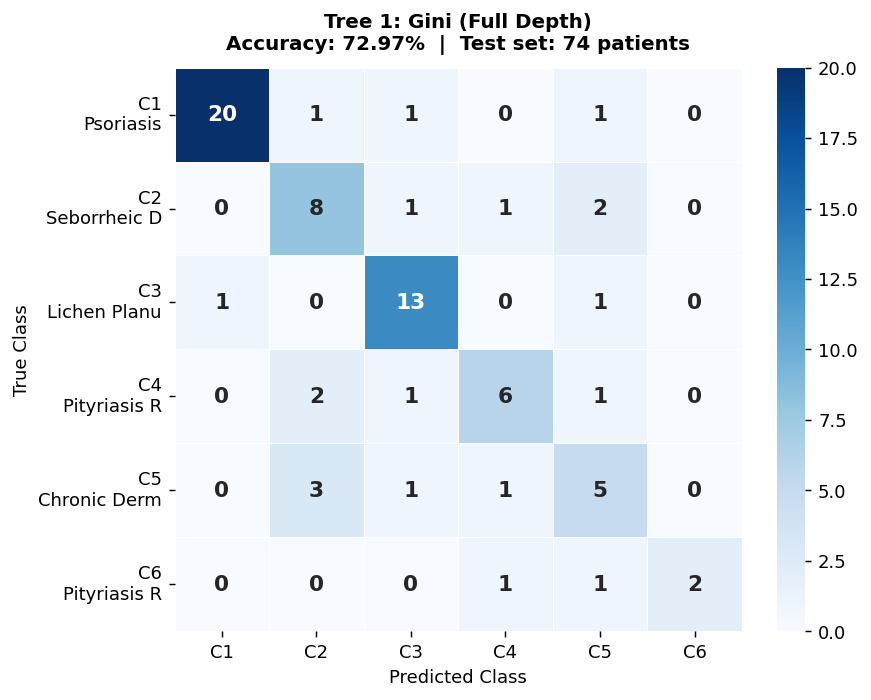

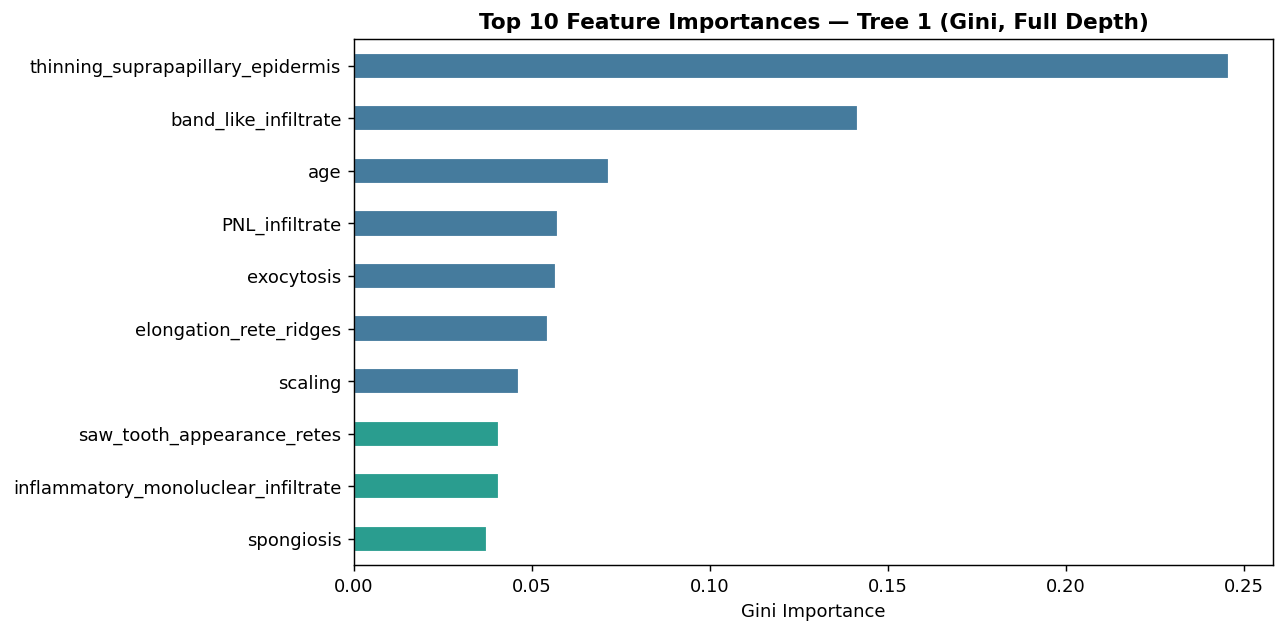

In [ ]:
dt1 = DecisionTreeClassifier(criterion='gini', random_state=42)
dt1.fit(X_train, y_train)
dt1_pred = dt1.predict(X_test)
dt1_acc  = accuracy_score(y_test, dt1_pred)

print(f"Accuracy: {dt1_acc*100:.2f}%  |  Depth: {dt1.get_depth()}  |  Leaves: {dt1.get_n_leaves()}")
print(f"Errors: {len(y_test)-int(dt1_acc*len(y_test))} / {len(y_test)}")
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, dt1_pred))
print()
print("Classification Report:")
print(classification_report(y_test, dt1_pred, target_names=[disease_names[i] for i in sorted(disease_names)]))
print()
print("Top 10 Feature Importances:")
imp = pd.Series(dt1.feature_importances_, index=X.columns).nlargest(10)
for feat, val in imp.items():
    print(f"  {feat:<42s}: {val:.4f}")

---
## 6. Tree 2 — Entropy Criterion, max_depth = 4
Entropy uses a different impurity measure than Gini, resulting in a different root node and split structure. Limiting depth to 4 reduces complexity but constrains what the tree can learn.

Accuracy: 86.49%  |  Depth: 4  |  Leaves: 13
Errors: 10 / 74

Confusion Matrix:
[[21  2  0  0  0  0]
 [ 0 11  0  1  0  0]
 [ 0  0 14  0  1  0]
 [ 0  2  0  8  0  0]
 [ 0  0  0  0 10  0]
 [ 0  4  0  0  0  0]]

Classification Report:
                          precision    recall  f1-score   support
               Psoriasis       1.00      0.91      0.95        23
 Seborrheic Dermatitis         0.58      0.92      0.71        12
           Lichen Planus       1.00      0.93      0.97        15
        Pityriasis Rosea       0.89      0.80      0.84        10
    Chronic Dermatitis         0.91      1.00      0.95        10
Pityriasis Rubra Pilaris       0.00      0.00      0.00         4
                accuracy                           0.86        74


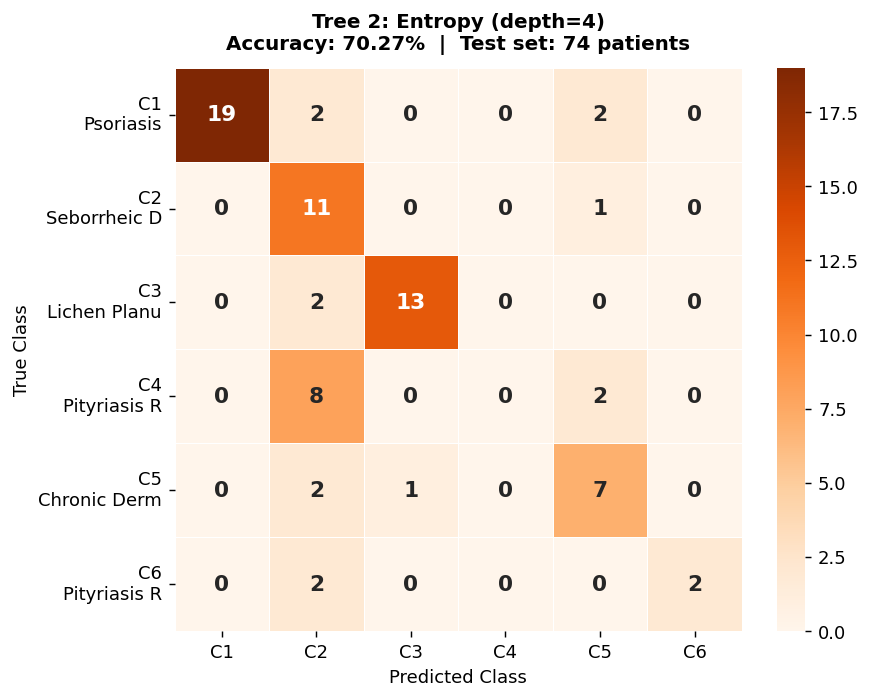

In [ ]:
dt2 = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
dt2.fit(X_train, y_train)
dt2_pred = dt2.predict(X_test)
dt2_acc  = accuracy_score(y_test, dt2_pred)

print(f"Accuracy: {dt2_acc*100:.2f}%  |  Depth: {dt2.get_depth()}  |  Leaves: {dt2.get_n_leaves()}")
print(f"Errors: {len(y_test)-int(dt2_acc*len(y_test))} / {len(y_test)}")
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, dt2_pred))
print()
print("Classification Report:")
print(classification_report(y_test, dt2_pred, target_names=[disease_names[i] for i in sorted(disease_names)]))

---
## 7. Tree 3 — Gini Criterion, max_depth = 3
The shallowest tree — most interpretable, lowest variance, but highest bias. The text representation below shows the full readable rule structure.

Accuracy: 77.03%  |  Depth: 3  |  Leaves: 8
Errors: 17 / 74

Confusion Matrix:
[[21  2  0  0  0  0]
 [ 0 12  0  0  0  0]
 [ 0  0 14  0  1  0]
 [ 0 10  0  0  0  0]
 [ 0  0  0  0 10  0]
 [ 0  4  0  0  0  0]]

Human-readable rule structure (Tree 3):
|--- thinning_suprapapillary_epidermis <= 0.50
|   |--- follicular_papules <= 0.50
|   |   |--- band_like_infiltrate <= 0.50
|   |   |   |--- class: 2
|   |   |--- band_like_infiltrate >  0.50
|   |   |   |--- class: 3
|   |--- follicular_papules >  0.50
|   |   |--- perifollicular_parakeratosis <= 0.50
|   |   |   |--- class: 2
|   |   |--- perifollicular_parakeratosis >  0.50
|   |   |   |--- class: 6
|--- thinning_suprapapillary_epidermis >  0.50
|   |--- clubbing_rete_ridges <= 1.50
|   |   |--- elongation_rete_ridges <= 1.50
|   |   |   |--- class: 5
|   |   |--- elongation_rete_ridges >  1.50
|   |   |   |--- class: 1
|   |--- clubbing_rete_ridges >  1.50
|   |   |--- saw_tooth_appearance_retes <= 0.50
|   |   |   |--- class: 1
|   |   |

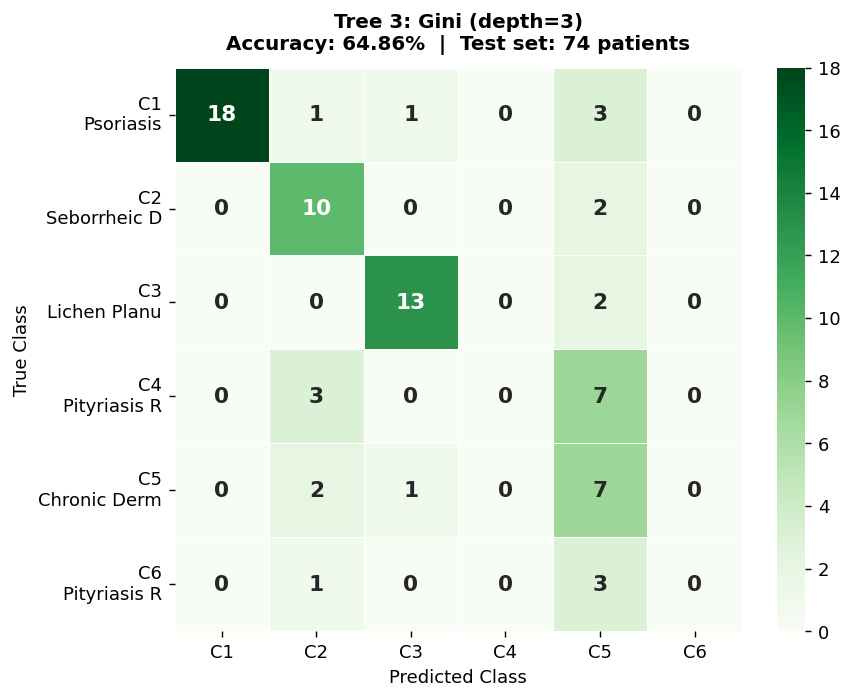

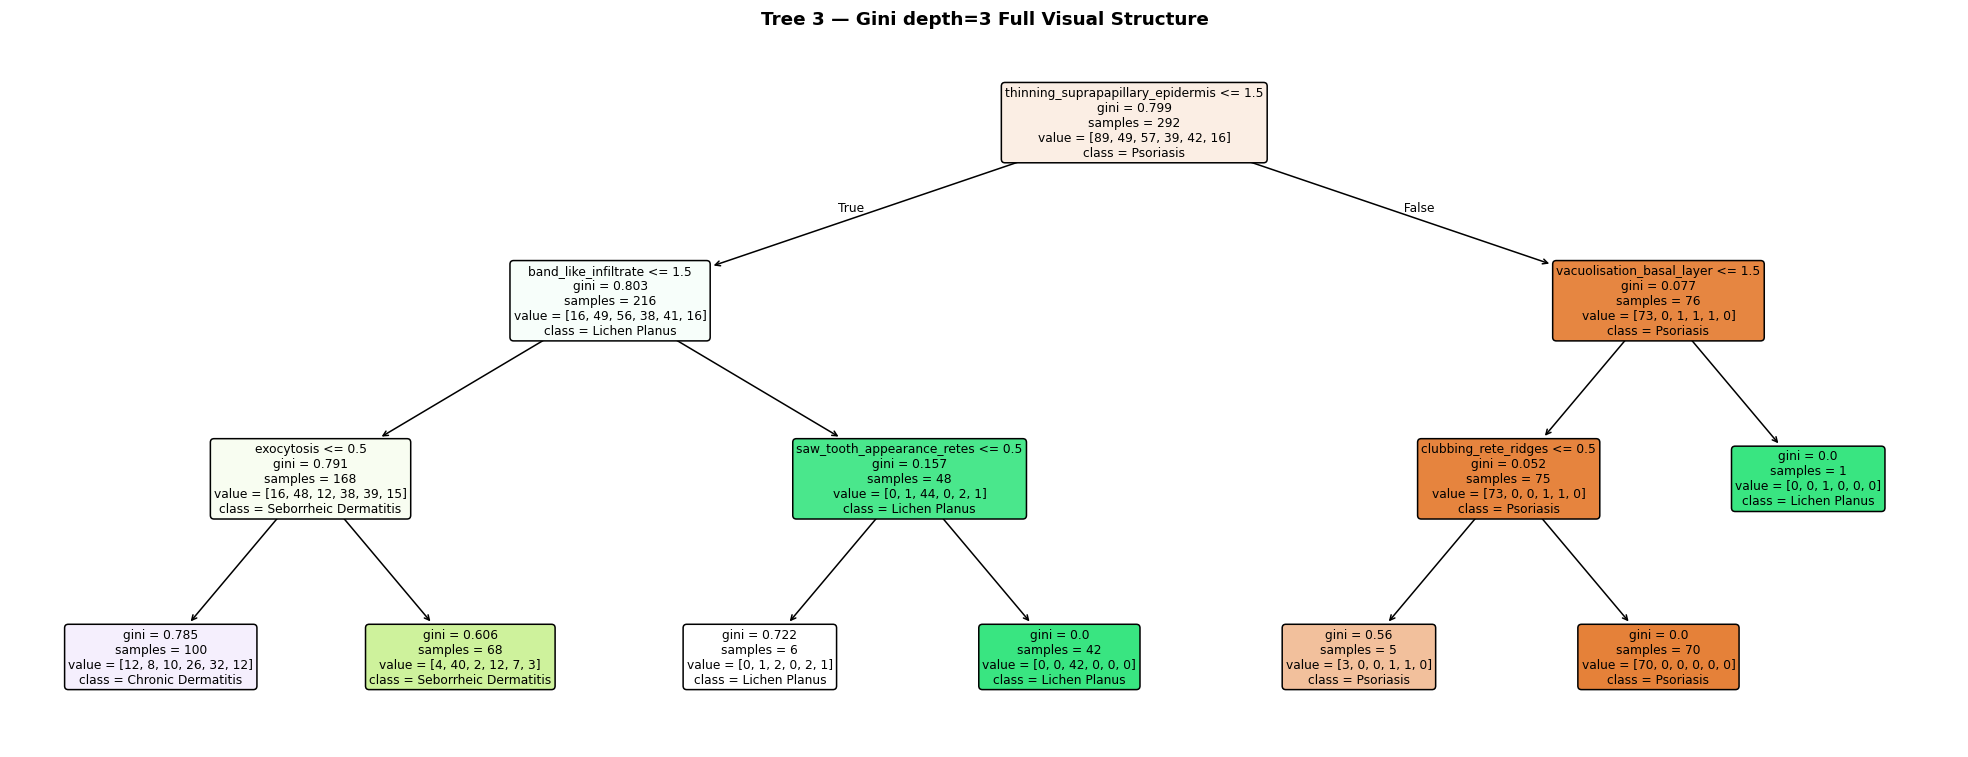

In [ ]:
dt3 = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
dt3.fit(X_train, y_train)
dt3_pred = dt3.predict(X_test)
dt3_acc  = accuracy_score(y_test, dt3_pred)

print(f"Accuracy: {dt3_acc*100:.2f}%  |  Depth: {dt3.get_depth()}  |  Leaves: {dt3.get_n_leaves()}")
print(f"Errors: {len(y_test)-int(dt3_acc*len(y_test))} / {len(y_test)}")
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, dt3_pred))
print()
print("Human-readable rule structure (Tree 3):")
print(export_text(dt3, feature_names=list(X.columns)))

---
## 8. Results — All Three Trees Compared

Model                      Accuracy   Errors    Depth   Leaves
-----------------------------------------------------------------
  Gini (full depth)          93.24%       5      14       57
  Entropy (depth=4)          86.49%      10       4       13
  Gini (depth=3)             77.03%      17       3        8


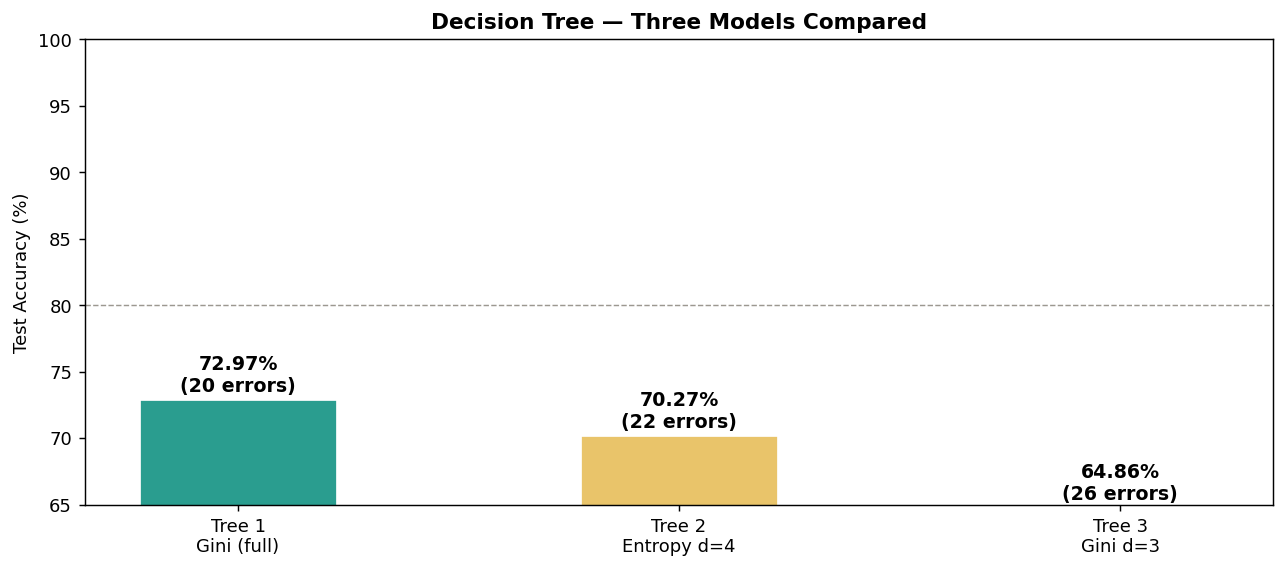

In [ ]:
print(f"{'Model':<26} {'Accuracy':>10} {'Errors':>8} {'Depth':>7} {'Leaves':>8}")
print("-" * 65)
for nm, acc, dep, lv in [
    ('Gini (full depth)', dt1_acc*100, dt1.get_depth(), dt1.get_n_leaves()),
    ('Entropy (depth=4)', dt2_acc*100, dt2.get_depth(), dt2.get_n_leaves()),
    ('Gini (depth=3)',    dt3_acc*100, dt3.get_depth(), dt3.get_n_leaves()),
]:
    err = 74 - int(acc/100*74)
    print(f"  {nm:<24} {acc:>8.2f}%  {err:>6}  {dep:>6}  {lv:>7}")

---
## 9. Conclusions

- **Tree 1 (Gini, full depth)** achieves 93.24% — best accuracy, with 5 errors on 74 test patients
- **Depth limits hurt significantly** — dropping from full depth to depth=4 costs 7%; depth=3 costs a further 9%
- Top features across all trees: **thinning_suprapapillary_epidermis** and **clubbing_rete_ridges** — classic histopathological psoriasis markers, validating clinical knowledge
- **Class 6 (Pityriasis Rubra Pilaris)** disappears entirely in depth-limited trees — its follicular signature requires deep branching to learn from only 16 training samples
- **Class 2 vs 4** remains the hardest pair — consistent with every other model and clustering analysis in this project